In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax
from typing import Sequence, Dict, Any


In [24]:
datafile = np.load("../data_new/cosmo_parallel_results_bin4_theta30.npz", allow_pickle=True)

data = datafile["results"]

results = data.tolist()             # convert to list of python dicts

cosmo_id = np.array([r["cosmo_id"] for r in results])

params = np.array([r["params"] for r in results])
Om      = np.array([r["params"]["Om"]      for r in results])
sigma8  = np.array([r["params"]["sigma8"]  for r in results])
w_       = np.array([r["params"]["w"]       for r in results])
h       = np.array([r["params"]["h"]       for r in results])
ns      = np.array([r["params"]["ns"]      for r in results])
Ob      = np.array([r["params"]["Ob"]      for r in results])
Oc      = np.array([r["params"]["Oc"]      for r in results])
wa      = np.array([r["params"]["wa"]      for r in results])


kappa_fix = np.array([r["kappa_fix"] for r in results], dtype=object)
snr_fix   = np.array([r["snr_fix"]   for r in results], dtype=object)


theory_l1_kappa_fix = np.array([r["theory_l1_kappa_fix"] for r in results], dtype=object)
theory_l1_snr_fix   = np.array([r["theory_l1_snr_fix"]   for r in results], dtype=object)
pred_stats          = np.array([r["pred_stats"]          for r in results], dtype=object)

cg_l1_kappa_mean = np.array([r["cg_l1_kappa_mean"] for r in results])
cg_l1_snr_mean   = np.array([r["cg_l1_snr_mean"]   for r in results])

cg_variance_mean = np.array([r["cg_variance_mean"] for r in results])
cg_variance_std  = np.array([r["cg_variance_std"]  for r in results])

cg_l1_kappa_std = np.array([r["cg_l1_kappa_std"] for r in results])
cg_l1_snr_std   = np.array([r["cg_l1_snr_std"]   for r in results])

cg_l1_kappa_realizations = np.array(
    [r["cg_l1_kappa_realizations"] for r in results], dtype=object
)

cg_l1_snr_realizations = np.array(
    [r["cg_l1_snr_realizations"] for r in results], dtype=object
)

datafile = np.load("cosmo_parallel_results_bin4_Fiducial_theta30.npz", allow_pickle=True)

data_fiducial = datafile["results"]

results_fiducial = data_fiducial.tolist()             # convert to list of python dicts

cosmo_id = np.array([r["cosmo_id"] for r in results_fiducial])
#add _fiducial to variable names
Om_fiducial      = np.array([r["params"]["Om"]      for r in results_fiducial])
sigma8_fiducial  = np.array([r["params"]["sigma8"]  for r in results_fiducial])
w_fiducial       = np.array([r["params"]["w"]       for r in results_fiducial])
h_fiducial       = np.array([r["params"]["h"]       for r in results_fiducial])
ns_fiducial      = np.array([r["params"]["ns"]      for r in results_fiducial])
Ob_fiducial      = np.array([r["params"]["Ob"]      for r in results_fiducial])
Oc_fiducial      = np.array([r["params"]["Oc"]      for r in results_fiducial])
wa_fiducial      = np.array([r["params"]["wa"]      for r in results_fiducial])


kappa_fix_fiducial = np.array([r["kappa_fix"] for r in results_fiducial], dtype=object)
snr_fix_fiducial   = np.array([r["snr_fix"]   for r in results_fiducial], dtype=object)

theory_l1_kappa_fix_fiducial = np.array([r["theory_l1_kappa_fix"] for r in results_fiducial], dtype=object)
theory_l1_snr_fix_fiducial   = np.array([r["theory_l1_snr_fix"]   for r in results_fiducial], dtype=object)
pred_stats_fiducial         = np.array([r["pred_stats"]          for r in results_fiducial], dtype=object)

cg_l1_kappa_mean_fiducial = np.array([r["cg_l1_kappa_mean"] for r in results_fiducial])
cg_l1_snr_mean_fiducial   = np.array([r["cg_l1_snr_mean"]   for r in results_fiducial])

cg_variance_mean_fiducial = np.array([r["cg_variance_mean"] for r in results_fiducial])
cg_variance_std_fiducial  = np.array([r["cg_variance_std"]  for r in results_fiducial])

cg_l1_kappa_std_fiducial = np.array([r["cg_l1_kappa_std"] for r in results_fiducial])
cg_l1_snr_std_fiducial   = np.array([r["cg_l1_snr_std"]   for r in results_fiducial])
cg_l1_kappa_realizations_fiducial = np.array([r["cg_l1_kappa_realizations"] for r in results_fiducial], dtype=object)

cg_l1_snr_realizations_fiducial = np.array(
    [r["cg_l1_snr_realizations"] for r in results_fiducial], dtype=object
)


#print the shapes of all the variables

print("Shapes of variables:")
print("cosmo_id:", cosmo_id.shape)
print("Om:", Om.shape)
print("sigma8:", sigma8.shape)
print("w:", w_.shape)
print("h:", h.shape)
print("ns:", ns.shape)
print("Ob:", Ob.shape)
print("Oc:", Oc.shape)
print("wa:", wa.shape)      
print("kappa_fix:", kappa_fix.shape)
print("snr_fix:", snr_fix.shape)
print("theory_l1_kappa_fix:", theory_l1_kappa_fix.shape)
print("theory_l1_snr_fix:", theory_l1_snr_fix.shape)
print("pred_stats:", pred_stats.shape)
print("cg_l1_kappa_mean:", cg_l1_kappa_mean.shape)
print("cg_l1_snr_mean:", cg_l1_snr_mean.shape)
print("cg_variance_mean:", cg_variance_mean.shape)
print("cg_variance_std:", cg_variance_std.shape)
print("cg_l1_kappa_std:", cg_l1_kappa_std.shape)
print("cg_l1_snr_std:", cg_l1_snr_std.shape)
print("cg_l1_kappa_realizations:", cg_l1_kappa_realizations.shape)
print("cg_l1_snr_realizations:", cg_l1_snr_realizations.shape)      
print("Fiducial Shapes of variables:")
print("cosmo_id:", cosmo_id.shape)
print("Om_fiducial:", Om_fiducial.shape)
print("sigma8_fiducial:", sigma8_fiducial.shape)
print("w_fiducial:", w_fiducial.shape)
print("h_fiducial:", h_fiducial.shape)
print("ns_fiducial:", ns_fiducial.shape)
print("Ob_fiducial:", Ob_fiducial.shape)
print("Oc_fiducial:", Oc_fiducial.shape)
print("wa_fiducial:", wa_fiducial.shape)      
print("kappa_fix_fiducial:", kappa_fix_fiducial.shape)
print("snr_fix_fiducial:", snr_fix_fiducial.shape)
print("theory_l1_kappa_fix_fiducial:", theory_l1_kappa_fix_fiducial.shape)
print("theory_l1_snr_fix_fiducial:", theory_l1_snr_fix_fiducial.shape)
print("pred_stats_fiducial:", pred_stats_fiducial.shape)
print("cg_l1_kappa_mean_fiducial:", cg_l1_kappa_mean_fiducial.shape)
print("cg_l1_snr_mean_fiducial:", cg_l1_snr_mean_fiducial.shape)    
print("cg_variance_mean_fiducial:", cg_variance_mean_fiducial.shape)
print("cg_variance_std_fiducial:", cg_variance_std_fiducial.shape)
print("cg_l1_kappa_std_fiducial:", cg_l1_kappa_std_fiducial.shape)
print("cg_l1_snr_std_fiducial:", cg_l1_snr_std_fiducial.shape)
print("cg_l1_kappa_realizations_fiducial:", cg_l1_kappa_realizations_fiducial.shape)
print("cg_l1_snr_realizations_fiducial:", cg_l1_snr_realizations_fiducial.shape)    




Shapes of variables:
cosmo_id: (1,)
Om: (186,)
sigma8: (186,)
w: (186,)
h: (186,)
ns: (186,)
Ob: (186,)
Oc: (186,)
wa: (186,)
kappa_fix: (186, 400)
snr_fix: (186, 300)
theory_l1_kappa_fix: (186, 400)
theory_l1_snr_fix: (186, 300)
pred_stats: (186, 5)
cg_l1_kappa_mean: (186, 400)
cg_l1_snr_mean: (186, 300)
cg_variance_mean: (186,)
cg_variance_std: (186,)
cg_l1_kappa_std: (186, 400)
cg_l1_snr_std: (186, 300)
cg_l1_kappa_realizations: (186,)
cg_l1_snr_realizations: (186,)
Fiducial Shapes of variables:
cosmo_id: (1,)
Om_fiducial: (1,)
sigma8_fiducial: (1,)
w_fiducial: (1,)
h_fiducial: (1,)
ns_fiducial: (1,)
Ob_fiducial: (1,)
Oc_fiducial: (1,)
wa_fiducial: (1,)
kappa_fix_fiducial: (1, 400)
snr_fix_fiducial: (1, 300)
theory_l1_kappa_fix_fiducial: (1, 400)
theory_l1_snr_fix_fiducial: (1, 300)
pred_stats_fiducial: (1, 5)
cg_l1_kappa_mean_fiducial: (1, 400)
cg_l1_snr_mean_fiducial: (1, 300)
cg_variance_mean_fiducial: (1,)
cg_variance_std_fiducial: (1,)
cg_l1_kappa_std_fiducial: (1, 400)
cg_l1_s

In [25]:
class LikelihoodNet(nn.Module):
    dim_x: int
    hidden_sizes: Sequence[int] = (128, 128, 128)

    @nn.compact
    def __call__(self, theta):
        x = theta
        for h in self.hidden_sizes:
            x = nn.relu(nn.Dense(h)(x))
        mean = nn.Dense(self.dim_x)(x)
        # keep log_std in a reasonable range using tanh
        log_std = nn.Dense(self.dim_x)(x)
        log_std = nn.tanh(log_std) * 2.0  # roughly in [-2, 2]
        return mean, log_std


def gaussian_log_prob(mean, log_std, x):
    """
    Diagonal Gaussian log p(x | mean, log_std) per sample.
    mean, log_std, x: (..., dim_x)
    returns: (...,)
    """
    var = jnp.exp(2.0 * log_std)
    return -0.5 * jnp.sum(
        ((x - mean) ** 2) / var + 2.0 * log_std + jnp.log(2.0 * jnp.pi),
        axis=-1,
    )


In [ ]:
def train_nle(
    theta_train: np.ndarray,
    x_train: np.ndarray,
    n_epochs: int = 200,
    batch_size: int = 256,
    lr: float = 1e-3,
    hidden_sizes: Sequence[int] = (128, 128, 128),
    seed: int = 0,
) -> Dict[str, Any]:
    """
    Train a neural likelihood estimator q_phi(x | theta).

    Parameters
    ----------
    theta_train : array, shape (N, dim_theta)
    x_train     : array, shape (N, dim_x)
    n_epochs    : number of epochs
    batch_size  : batch size
    lr          : learning rate
    hidden_sizes: tuple of hidden layer sizes
    seed        : RNG seed

    Returns
    -------
    model_dict : dict with keys:
        - "model": LikelihoodNet instance
        - "params": trained parameters
        - "theta_mean", "theta_std": normalisation stats
        - "x_mean", "x_std": normalisation stats
    """
    # ------------------------------------------
    # Convert to JAX arrays and compute stats
    # ------------------------------------------
    theta_train = np.asarray(theta_train, dtype=np.float32)
    x_train = np.asarray(x_train, dtype=np.float32)

    theta_mean = theta_train.mean(axis=0)
    theta_std = theta_train.std(axis=0)
    theta_std[theta_std == 0.0] = 1.0  # avoid division by zero

    x_mean = x_train.mean(axis=0)
    x_std = x_train.std(axis=0)
    x_std[x_std == 0.0] = 1.0

    theta_train_norm = (theta_train - theta_mean) / theta_std
    x_train_norm = (x_train - x_mean) / x_std

    theta_train_norm = jnp.asarray(theta_train_norm)
    x_train_norm = jnp.asarray(x_train_norm)

    N, dim_theta = theta_train.shape
    dim_x = x_train.shape[1]

    # ------------------------------------------
    # Build model & optimiser
    # ------------------------------------------
    model = LikelihoodNet(dim_x=dim_x, hidden_sizes=hidden_sizes)
    rng = jax.random.PRNGKey(seed)

    # initialise on a dummy batch
    init_theta = theta_train_norm[:1]
    params = model.init(rng, init_theta)

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)

    # ------------------------------------------
    # Training step (single batch)
    # ------------------------------------------
    @jax.jit
    def train_step(params, opt_state, theta_b, x_b):
        def loss_fn(p):
            mean, log_std = model.apply(p, theta_b)
            logp = gaussian_log_prob(mean, log_std, x_b)
            return -jnp.mean(logp)  # negative log-likelihood

        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state_new = optimizer.update(grads, opt_state, params)
        params_new = optax.apply_updates(params, updates)
        return params_new, opt_state_new, loss

    # ------------------------------------------
    # Epoch loop (Python-side batching)
    # ------------------------------------------
    for epoch in range(1, n_epochs + 1):
        perm = np.random.permutation(N)
        theta_shuff = theta_train_norm[perm]
        x_shuff = x_train_norm[perm]

        epoch_loss = 0.0
        n_batches = 0

        for start in range(0, N, batch_size):
            end = start + batch_size
            theta_b = theta_shuff[start:end]
            x_b = x_shuff[start:end]

            params, opt_state, loss = train_step(params, opt_state, theta_b, x_b)
            epoch_loss += float(loss)
            n_batches += 1

        epoch_loss /= max(n_batches, 1)
        if epoch % 10 == 0 or epoch == 1 or epoch == n_epochs:
            print(f"Epoch {epoch}/{n_epochs}  loss = {epoch_loss:.4f}")

    model_dict = {
        "model": model,
        "params": params,
        "theta_mean": jnp.asarray(theta_mean, dtype=jnp.float32),
        "theta_std": jnp.asarray(theta_std, dtype=jnp.float32),
        "x_mean": jnp.asarray(x_mean, dtype=jnp.float32),
        "x_std": jnp.asarray(x_std, dtype=jnp.float32),
    }
    return model_dict


In [27]:
def log_likelihood_nle(
    theta_phys: np.ndarray,
    x_phys: np.ndarray,
    model_dict: Dict[str, Any],
) -> float:
    """
    Log-likelihood log q_phi(x | theta) using the trained NLE.

    theta_phys: (dim_theta,)
    x_phys    : (dim_x,)
    """
    model = model_dict["model"]
    params = model_dict["params"]
    theta_mean = model_dict["theta_mean"]
    theta_std = model_dict["theta_std"]
    x_mean = model_dict["x_mean"]
    x_std = model_dict["x_std"]

    theta_phys = jnp.asarray(theta_phys, dtype=jnp.float32)
    x_phys = jnp.asarray(x_phys, dtype=jnp.float32)

    theta_norm = (theta_phys - theta_mean) / theta_std
    x_norm = (x_phys - x_mean) / x_std

    theta_norm = theta_norm[None, :]  # (1, dim_theta)
    x_norm = x_norm[None, :]          # (1, dim_x)

    mean, log_std = model.apply(params, theta_norm)
    logp = gaussian_log_prob(mean, log_std, x_norm)[0]
    return float(logp)


In [28]:
def make_uniform_prior_bounds(theta_train: np.ndarray):
    theta_train = np.asarray(theta_train, dtype=float)
    theta_min = theta_train.min(axis=0)
    theta_max = theta_train.max(axis=0)
    return theta_min, theta_max


def log_prior_uniform(theta_phys: np.ndarray,
                      theta_min: np.ndarray,
                      theta_max: np.ndarray) -> float:
    """
    Simple uniform prior over [theta_min, theta_max] in each dimension.
    """
    if np.all(theta_phys >= theta_min) and np.all(theta_phys <= theta_max):
        # constant within bounds; we can just return 0 (normalisation cancels)
        return 0.0
    else:
        return -np.inf


def make_log_posterior(model_dict: Dict[str, Any],
                       x_obs: np.ndarray,
                       theta_min: np.ndarray,
                       theta_max: np.ndarray):
    """
    Returns a Python callable log_post(theta_phys) using the NLE likelihood
    and uniform prior bounds.
    """

    x_obs = np.asarray(x_obs, dtype=np.float32)
    theta_min = np.asarray(theta_min, dtype=np.float32)
    theta_max = np.asarray(theta_max, dtype=np.float32)

    def log_post(theta_phys: np.ndarray) -> float:
        lp = log_prior_uniform(theta_phys, theta_min, theta_max)
        if not np.isfinite(lp):
            return -np.inf
        ll = log_likelihood_nle(theta_phys, x_obs, model_dict)
        return ll + lp

    return log_post


In [29]:
def sample_posterior_mh(
    log_post,
    theta_min: np.ndarray,
    theta_max: np.ndarray,
    n_samples: int = 5000,
    burn_in: int = 1000,
    step_scale: float = 0.02,
    rng_seed: int = 0,
) -> np.ndarray:
    """
    Random-walk Metropolis-Hastings sampler for p(theta | x_obs).

    Parameters
    ----------
    log_post   : callable(theta) -> float
    theta_min  : array, (dim_theta,)
    theta_max  : array, (dim_theta,)
    n_samples  : number of *kept* samples
    burn_in    : number of burn-in iterations
    step_scale : proposal std as fraction of prior width per dimension
    rng_seed   : seed for NumPy RNG

    Returns
    -------
    samples : array, shape (n_samples, dim_theta)
    """
    theta_min = np.asarray(theta_min, dtype=float)
    theta_max = np.asarray(theta_max, dtype=float)
    dim_theta = theta_min.shape[0]

    rng = np.random.default_rng(rng_seed)

    # initial position: center of prior box
    theta_curr = 0.5 * (theta_min + theta_max)
    logp_curr = log_post(theta_curr)

    # if starting point is invalid (e.g. low likelihood), try a few random inits
    tries = 0
    while not np.isfinite(logp_curr) and tries < 50:
        theta_curr = rng.uniform(theta_min, theta_max)
        logp_curr = log_post(theta_curr)
        tries += 1
    if not np.isfinite(logp_curr):
        raise RuntimeError("Could not find a valid starting point for MH.")

    width = theta_max - theta_min
    proposal_std = step_scale * width

    total_iters = n_samples + burn_in
    samples = np.zeros((n_samples, dim_theta), dtype=float)

    n_accept = 0
    kept = 0

    for t in range(total_iters):
        theta_prop = theta_curr + rng.normal(scale=proposal_std)
        # reflect back into bounds (simple way to keep in support)
        theta_prop = np.maximum(theta_prop, theta_min)
        theta_prop = np.minimum(theta_prop, theta_max)

        logp_prop = log_post(theta_prop)
        log_alpha = logp_prop - logp_curr

        if np.log(rng.uniform()) < log_alpha:
            theta_curr = theta_prop
            logp_curr = logp_prop
            if t >= burn_in:
                n_accept += 1

        if t >= burn_in:
            samples[kept] = theta_curr
            kept += 1
            if kept >= n_samples:
                break

    acc_rate = n_accept / max(n_samples, 1)
    print(f"[MH] Acceptance rate after burn-in: {acc_rate:.3f}")
    return samples


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import corner

def plot_two_posteriors_with_truth_and_legend(
    samples1, samples2,
    labels,
    truths,
    color1="red",
    color2="blue",
    truth_color="black",
    label1="Posterior 1",
    label2="Posterior 2",
    truth_label="Fiducial",
    alpha=0.45,
    bins=40,
    smooth=1.0,
    figsize=2.4,
):

    D = samples1.shape[1]

    # ---- First posterior ----
    fig = corner.corner(
        samples1,
        bins=bins,
        labels=labels,
        color=color1,
        smooth=smooth,
        smooth1d=True,
        plot_contours=True,
        fill_contours=True,
        fill_alpha=alpha,
        contour_kwargs={"linewidths": 1.4},
        plot_datapoints=False,
        max_n_ticks=4,
        figsize=(figsize * D, figsize * D),
    )

    # ---- Second posterior ----
    corner.corner(
        samples2,
        bins=bins,
        labels=labels,
        color=color2,
        smooth=smooth,
        smooth1d=True,
        plot_contours=True,
        fill_contours=True,
        fill_alpha=alpha,
        contour_kwargs={"linewidths": 1.4},
        plot_datapoints=False,
        max_n_ticks=4,
        fig=fig,
    )

    # ---- Add vertical fiducial lines ----
    axes = np.array(fig.axes).reshape((D, D))
    for i in range(D):
        ax = axes[i, i]
        ax.axvline(truths[i], color=truth_color, lw=2, alpha=0.8)

    # ---- Build Legend ----
    # Create "dummy" artists that appear in the legend
    import matplotlib.patches as mpatches
    patch1 = mpatches.Patch(color=color1, alpha=alpha, label=label1)
    patch2 = mpatches.Patch


theory_reb shape: (186, 40)
length of sim_reb: 186
Skipped 36 invalid cosmologies.


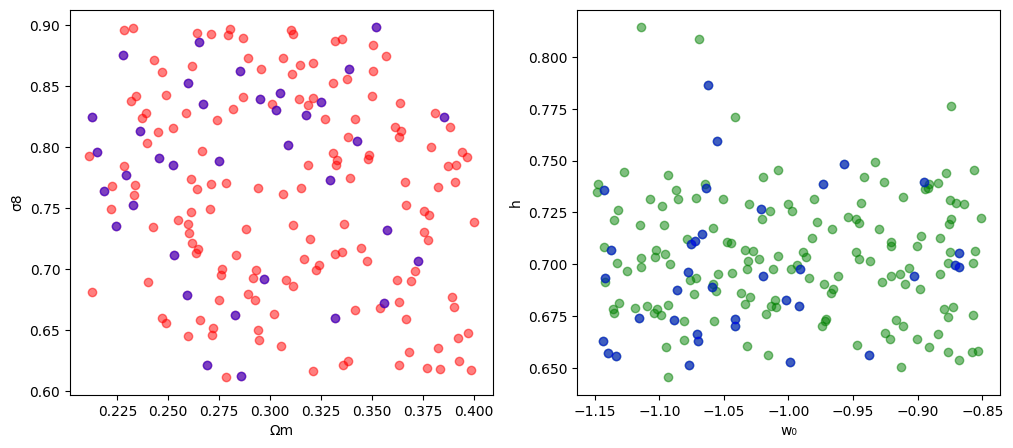

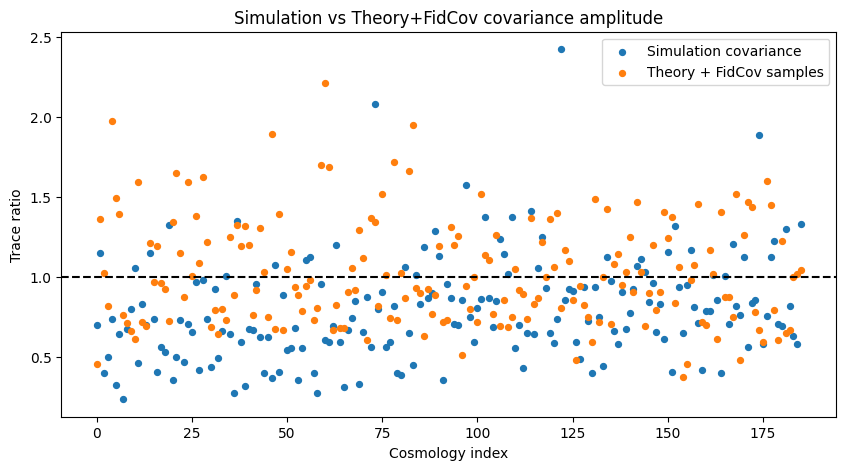

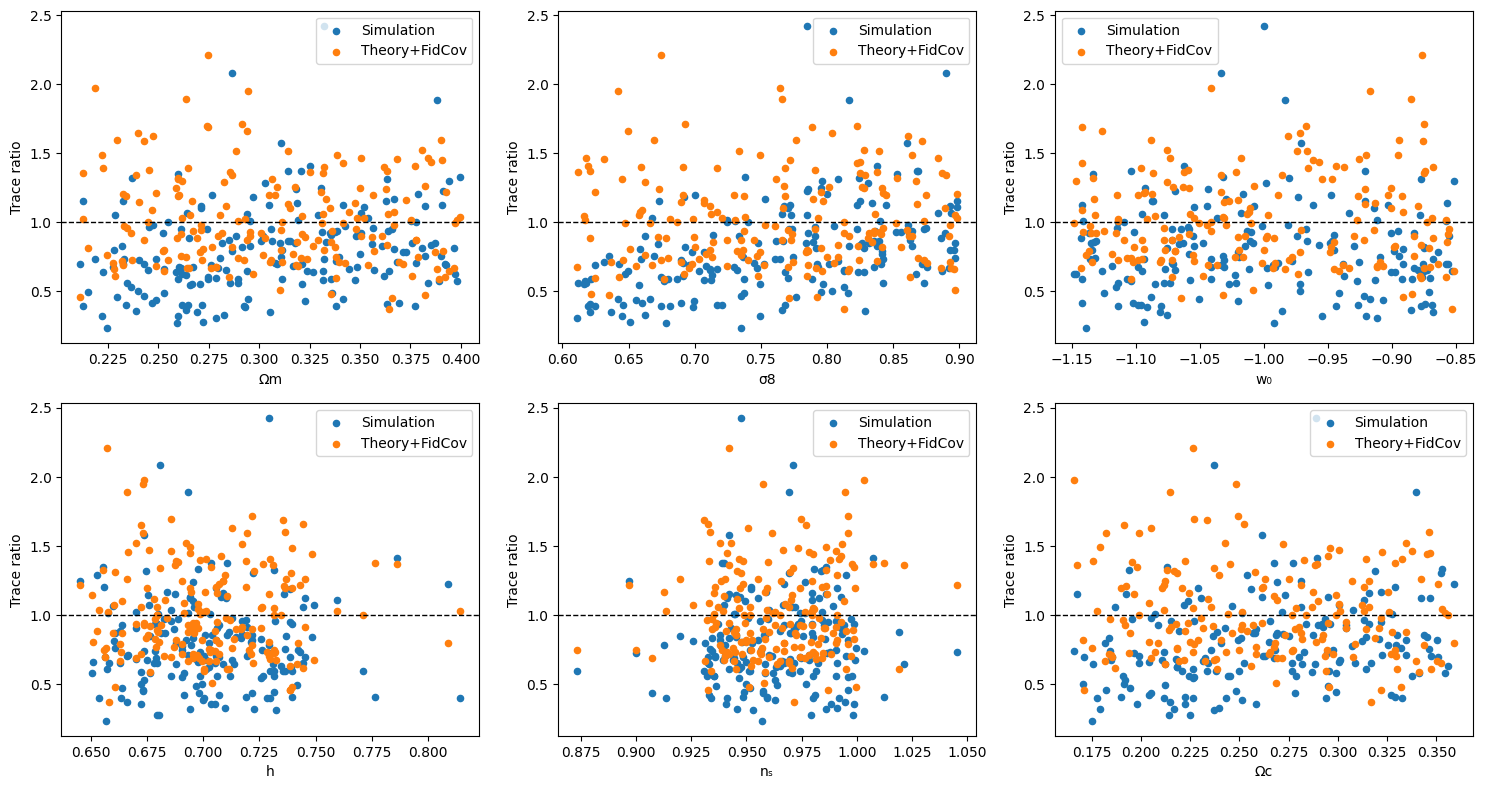

In [39]:

# =====================================================
# 1. Rebin function
# =====================================================
def rebin_2d(arr, new_bins):
    """
    Downsample the second axis of a 2D array by averaging contiguous blocks.

    Parameters
    ----------
    arr : array_like, shape (N_real, old_bins)
    new_bins : int

    Returns
    -------
    rebinned : ndarray, shape (N_real, new_bins)
    """
    arr = np.asarray(arr, dtype=float)
    old_bins = arr.shape[1]
    factor = old_bins // new_bins

    trimmed = arr[:, :factor * new_bins]
    return trimmed.reshape(arr.shape[0], new_bins, factor).mean(axis=2)


# =====================================================
# 2. Rebin fiducial and theory arrays
# =====================================================
new_bins = 40
fid_arr = np.asarray(cg_l1_kappa_realizations_fiducial[0], dtype=float)  # (N_real, old_bins)
fid_arr_reb = rebin_2d(fid_arr, new_bins) if fid_arr.shape[1] != new_bins else fid_arr

theory = np.asarray(theory_l1_kappa_fix, dtype=float)                    # (ncosmo, old_bins)
theory_reb = rebin_2d(theory, new_bins) if theory.shape[1] != new_bins else theory

sim_reb = []
for sims in cg_l1_kappa_realizations:   # shape (ncosmo, nreal, old_bins)
    sims = np.asarray(sims, dtype=float)
    if sims.shape[1] != new_bins:
        sim_reb.append(rebin_2d(sims, new_bins))
    else:
        sim_reb.append(sims)

sim_reb = np.array(sim_reb, dtype=object)  # shape (ncosmo,), each element is (nreal, new_bins)


print("theory_reb shape:", theory_reb.shape)
print("length of sim_reb:", len(sim_reb))


# =====================================================
# 3. Draw multivariate samples for each cosmology
# =====================================================
nsamples = 7
ncosmo, nbins = theory_reb.shape

samples_theory_fidcov = []
samples_sim_fidcov = []
invalid_cosmos = []


Cov_fid = np.cov(fid_arr_reb, rowvar=False)
eps = 1e-6 * np.mean(np.diag(Cov_fid))
Cov_fid_reg = Cov_fid #+ eps * np.eye(Cov_fid.shape[0])

for i in range(ncosmo):

    # Skip cosmologies with negative PDF issues
    if np.any(theory_l1_kappa_fix[i] < -1e-3):
        invalid_cosmos.append(i)
        # continue
    # elif pred_stats[i][0] > 1e-7: 
    #     invalid_cosmos.append(i)
        # continue

    mean_i = theory_reb[i]
    draws = np.random.multivariate_normal(mean=mean_i,
                                          cov=Cov_fid_reg,
                                          size=nsamples)
    samples_theory_fidcov.append(draws)
    mean_sim_i = np.mean(sim_reb[i], axis=0)
    draws_sim = np.random.multivariate_normal(mean=mean_sim_i,
                                             cov=Cov_fid_reg,
                                             size=nsamples)
    samples_sim_fidcov.append(draws_sim)

print(f"Skipped {len(invalid_cosmos)} invalid cosmologies.")
samples_theory_fidcov = np.array(samples_theory_fidcov, dtype=object)
samples_sim_fidcov = np.array(samples_sim_fidcov, dtype=object)

# =====================================================
# 4. Visualise parameter space and invalid cosmologies
# =====================================================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(Om, sigma8, color='red', alpha=0.5, label="All")
axs[1].scatter(w_, h, color='green', alpha=0.5, label="All")

for idx in invalid_cosmos:
    axs[0].scatter(Om[idx], sigma8[idx], color='blue', alpha=0.5)
    axs[1].scatter(w_[idx], h[idx], color='blue', alpha=0.5)

axs[0].set_xlabel("Ωm")
axs[0].set_ylabel("σ8")
axs[1].set_xlabel("w₀")
axs[1].set_ylabel("h")
plt.show()


# =====================================================
# 5. Covariance amplitude comparison (trace, Frobenius)
# =====================================================
trace_ratios_samples = []
frob_ratios_samples = []

fid_trace = np.trace(Cov_fid_reg)
fid_frob  = np.linalg.norm(Cov_fid_reg, "fro")

for draws in samples_theory_fidcov:

    arr = np.asarray(draws, dtype=float)  # (7, nbins)
    Cov_samp = np.cov(arr, rowvar=False)

    trace_ratios_samples.append(np.trace(Cov_samp) / fid_trace)
    frob_ratios_samples.append(np.linalg.norm(Cov_samp, "fro") / fid_frob)

trace_ratios_samples = np.array(trace_ratios_samples)
frob_ratios_samples = np.array(frob_ratios_samples)

trace_ratios = []
frob_ratios = []
for simrel in sim_reb:      # <- simulation covariance list
    Cov_sim_i = np.cov(simrel, rowvar=False)
    tr_ratio  = np.trace(Cov_sim_i) / fid_trace
    fr_ratio  = np.linalg.norm(Cov_sim_i, "fro") / fid_frob
    trace_ratios.append(tr_ratio)
    frob_ratios.append(fr_ratio)

trace_ratios = np.array(trace_ratios)
frob_ratios  = np.array(frob_ratios)

# =====================================================
# 6. Plot amplitude vs cosmology index
# =====================================================
plt.figure(figsize=(10, 5))
plt.scatter(np.arange(ncosmo), trace_ratios, s=18, label="Simulation covariance")
plt.scatter(np.arange(len(samples_theory_fidcov)), trace_ratios_samples,
            s=18, label="Theory + FidCov samples")
plt.axhline(1, color="black", linestyle="--")
plt.xlabel("Cosmology index")
plt.ylabel("Trace ratio")
plt.legend()
plt.title("Simulation vs Theory+FidCov covariance amplitude")
plt.show()


# =====================================================
# 7. Scatter vs a parameter (example: sigma8)
# =====================================================
params = {
    "Ωm": Om,
    "σ8": sigma8,
    "w₀": w_,
    "h": h,
    "nₛ": ns,
    "Ωc": Oc,

}

def plot_trace_vs_all(params, trace_sim, trace_draws):
    n = len(params)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axs = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
    axs = axs.flatten()

    for ax, (name, arr) in zip(axs, params.items()):
        ax.scatter(arr, trace_sim, s=20, label="Simulation")
        ax.scatter(arr, trace_draws, s=20, label="Theory+FidCov")
        ax.axhline(1, color="black", linestyle="--", lw=1)
        ax.set_xlabel(name)
        ax.set_ylabel("Trace ratio")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_trace_vs_all(params, trace_ratios, trace_ratios_samples)


In [40]:
# =====================================================
# Build parameter–data pairs for NPE
# =====================================================

# --- stack all parameter arrays into theta vectors ---
theta_all = np.column_stack([Om, sigma8, w_, h, ns, Oc])
dim_theta = theta_all.shape[1]
print("theta_all shape:", theta_all.shape)

# --- create training data for theory samples ---
thetas_list = []
xs_list_theory = []
xs_list_sim = []

for i in range(ncosmo):
    if i in invalid_cosmos:
        continue
    draws = np.asarray(samples_theory_fidcov[i], dtype=float)  # (nsamples, nbins)
    theta_i = np.repeat(theta_all[i][None, :], draws.shape[0], axis=0)

    thetas_list.append(theta_i)
    xs_list_theory.append(draws)
    draws = np.asarray(samples_sim_fidcov[i], dtype=float)  # (nsamples, nbins)
    xs_list_sim.append(draws)

theta_train = np.vstack(thetas_list)   # (Ntrain, dim_theta)
x_train_theory     = np.vstack(xs_list_theory)       # (Ntrain, nbins)
x_train_sim = np.vstack(xs_list_sim)

print("theta_train:", theta_train.shape)
print("x_train_theory:",     x_train_theory.shape)
print("x_train_sim:",     x_train_sim.shape)

# # --- OPTIONAL: include simulations ---
# thetas_sim_list = []
# xs_sim_list = []

# for i in range(ncosmo):
#     sims = np.asarray(sim_reb[i], dtype=float)  # (nreal, nbins)
#     theta_i = np.repeat(theta_all[i][None, :], sims.shape[0], axis=0)

#     thetas_sim_list.append(theta_i)
#     xs_sim_list.append(sims)

# theta_train_sim = np.vstack(thetas_sim_list)
# x_train_sim     = np.vstack(xs_sim_list)

# print("theta_train_sim:", theta_train_sim.shape)
# print("x_train_sim:",     x_train_sim.shape)

# # --- combine theory+sim if needed ---
# theta_train_full = np.vstack([theta_train, theta_train_sim])
# x_train_full     = np.vstack([x_train,     x_train_sim])

# print("theta_train_full:", theta_train_full.shape)
# print("x_train_full:",     x_train_full.shape)

# --- define the true observation ---
x_obs = np.mean(fid_arr_reb, axis=0)
print("x_obs shape:", x_obs.shape)
print("x_train_theory shape:", x_train_theory.shape)
print("x_train_sim shape:", x_train_sim.shape)
print("len of invalid cosmos: ", len(invalid_cosmos))
print((186-len(invalid_cosmos)) * 7)

theta_all shape: (186, 6)
theta_train: (1050, 6)
x_train_theory: (1050, 40)
x_train_sim: (1050, 40)
x_obs shape: (40,)
x_train_theory shape: (1050, 40)
x_train_sim shape: (1050, 40)
len of invalid cosmos:  36
1050


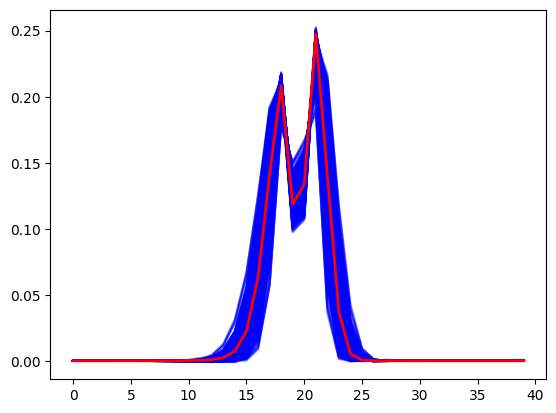

In [41]:
# plt.plot(x_train_sim.T, color="green", alpha=0.1)
plt.plot(x_train_theory.T, color="blue", alpha=0.1)
plt.plot(x_obs,c="red", lw=2)
plt.show()

In [56]:
model_dict = train_nle(
    theta_train,
    x_train_theory,
    n_epochs=500,
    batch_size=64,
    lr=1e-3,
    hidden_sizes=(128, 128, 128),
    seed=0,
)

theta_min, theta_max = make_uniform_prior_bounds(theta_train)
log_post = make_log_posterior(model_dict, x_obs, theta_min, theta_max)

theta_samples = sample_posterior_mh(
    log_post,
    theta_min=theta_min,
    theta_max=theta_max,
    n_samples=5000,
    burn_in=500,
    step_scale=0.05,
    rng_seed=42,
)

print("theta_samples shape:", theta_samples.shape)  # (5000, dim_theta)




[NLE] Epoch 1/500  loss = 56.8738
[NLE] Epoch 10/500  loss = -4.8173
[NLE] Epoch 20/500  loss = -10.9978
[NLE] Epoch 30/500  loss = -13.2406
[NLE] Epoch 40/500  loss = -13.9802
[NLE] Epoch 50/500  loss = -15.1173
[NLE] Epoch 60/500  loss = -15.5893
[NLE] Epoch 70/500  loss = -16.1964
[NLE] Epoch 80/500  loss = -16.3038
[NLE] Epoch 90/500  loss = -16.3919
[NLE] Epoch 100/500  loss = -17.0047
[NLE] Epoch 110/500  loss = -17.2849
[NLE] Epoch 120/500  loss = -17.2972
[NLE] Epoch 130/500  loss = -17.5362
[NLE] Epoch 140/500  loss = -17.5323
[NLE] Epoch 150/500  loss = -17.6994
[NLE] Epoch 160/500  loss = -17.8132
[NLE] Epoch 170/500  loss = -18.0699
[NLE] Epoch 180/500  loss = -18.0528
[NLE] Epoch 190/500  loss = -18.0517
[NLE] Epoch 200/500  loss = -18.3477
[NLE] Epoch 210/500  loss = -18.3656
[NLE] Epoch 220/500  loss = -18.5108
[NLE] Epoch 230/500  loss = -18.4953
[NLE] Epoch 240/500  loss = -18.6596
[NLE] Epoch 250/500  loss = -18.6681
[NLE] Epoch 260/500  loss = -18.7247
[NLE] Epoch 27

In [46]:
model_dict = train_nle(
    theta_train,
    x_train_sim,
    n_epochs=500,
    batch_size=64,
    lr=1e-3,
    hidden_sizes=(128, 128, 128),
    seed=0,
)

theta_min, theta_max = make_uniform_prior_bounds(theta_train)
log_post = make_log_posterior(model_dict, x_obs, theta_min, theta_max)

theta_samples_sim = sample_posterior_mh(
    log_post,
    theta_min=theta_min,
    theta_max=theta_max,
    n_samples=30000,
    burn_in=3000,
    step_scale=0.03,
    rng_seed=42,
)

print("theta_samples shape:", theta_samples.shape)  # (5000, dim_theta)



[NLE] Epoch 1/500  loss = 61.4586
[NLE] Epoch 10/500  loss = 14.5847
[NLE] Epoch 20/500  loss = 10.9607
[NLE] Epoch 30/500  loss = 9.8699
[NLE] Epoch 40/500  loss = 9.2913
[NLE] Epoch 50/500  loss = 9.0355
[NLE] Epoch 60/500  loss = 8.8484
[NLE] Epoch 70/500  loss = 8.3863
[NLE] Epoch 80/500  loss = 8.1159
[NLE] Epoch 90/500  loss = 7.9748
[NLE] Epoch 100/500  loss = 7.7891
[NLE] Epoch 110/500  loss = 7.7327
[NLE] Epoch 120/500  loss = 7.3447
[NLE] Epoch 130/500  loss = 7.6855
[NLE] Epoch 140/500  loss = 7.3359
[NLE] Epoch 150/500  loss = 7.1383
[NLE] Epoch 160/500  loss = 7.1095
[NLE] Epoch 170/500  loss = 6.9520
[NLE] Epoch 180/500  loss = 6.8868
[NLE] Epoch 190/500  loss = 6.8920
[NLE] Epoch 200/500  loss = 6.8418
[NLE] Epoch 210/500  loss = 6.7207
[NLE] Epoch 220/500  loss = 6.5774
[NLE] Epoch 230/500  loss = 6.6582
[NLE] Epoch 240/500  loss = 6.5637
[NLE] Epoch 250/500  loss = 6.5193
[NLE] Epoch 260/500  loss = 6.4719
[NLE] Epoch 270/500  loss = 6.3765
[NLE] Epoch 280/500  loss = 

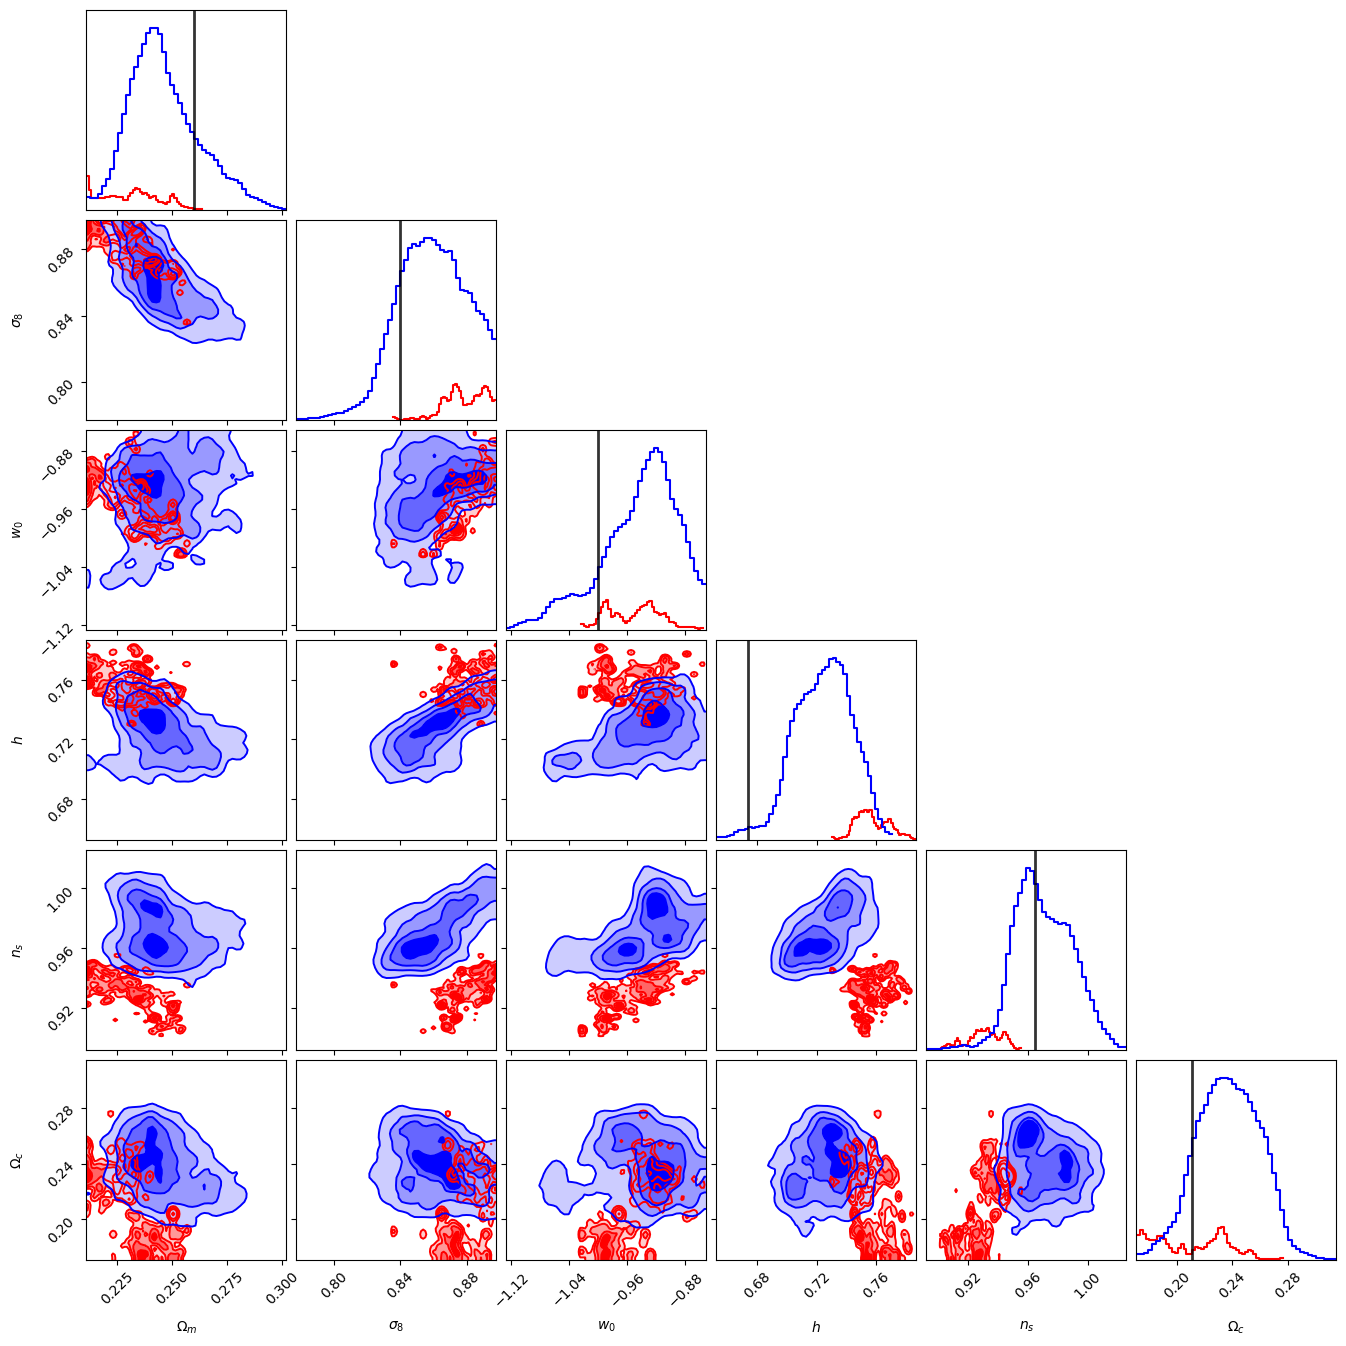

In [57]:
labels = [
    r"$\Omega_m$",
    r"$\sigma_8$",
    r"$w_0$",
    r"$h$",
    r"$n_s$",
    r"$\Omega_c$",
]

theta_truths = np.array([
    Om_fiducial[0],
    sigma8_fiducial[0],
    w_fiducial[0],
    h_fiducial[0],
    ns_fiducial[0],
    Oc_fiducial[0],
])

fig = plot_two_posteriors_with_truth_and_legend(
    theta_samples,
    theta_samples_sim,
    labels=labels,
    truths=theta_truths,
    color1="red",
    color2="blue",
    label1="Simulation posterior",
    label2="Theory posterior",
    truth_label="Fiducial",
    alpha=0.4,
    bins=50,
    smooth=1.2
)

plt.show()

